In [4]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

In [ ]:
# Colunas que serão usadas para o estudo
columns = [
    'make',
    'model',
    'variant',
    'yearFrom',
    'yearTo',
    'bodyType',
    'doors',
    'seats',
    'engineFuelType',
    'enginePowerBhp',
    'gearboxType',
    'gears',
    'drivetrain',
    'topSpeedKph',
    'fuelTankLitres'
]
# Visualizando dados
df = pd.read_csv(fr".\data\ford-specifications.csv")
df_honda = pd.read_csv(fr".\data\honda-specifications.csv")
df_hyundai = pd.read_csv(fr".\data\honda-specifications.csv")
print(df.columns)
print(df.head())
print(df.info())
print(df.describe)

Index(['make', 'model', 'variant', 'yearFrom', 'yearTo', 'bodyType', 'doors',
       'seats', 'engineCode', 'engineDisplacement', 'engineCylinders',
       'engineValves', 'engineFuelType', 'enginePowerBhp', 'enginePowerKw',
       'engineTorqueNm', 'engineAspiration', 'enginePosition', 'gearboxType',
       'gears', 'drivetrain', 'acceleration0100', 'topSpeedKph', 'topSpeedMph',
       'fuelEconomyCombinedMpg', 'fuelEconomyCombinedL100',
       'fuelEconomyUrbanL100', 'fuelEconomyExtraUrbanL100', 'fuelTankLitres',
       'co2Gkm', 'emissionsStandard', 'noxMgkm', 'lengthMm', 'widthMm',
       'heightMm', 'wheelbaseMm', 'weightKg', 'grossWeightKg', 'bootLitres',
       'bootLitresMax', 'tyreFront', 'tyreRear', 'brakeFront', 'brakeRear',
       'batteryKwh', 'electricRangeKm', 'chargingKw'],
      dtype='object')
   make            model                           variant  yearFrom  yearTo  \
0  FORD  2010Ford Taurus      3.5L V6 Duratec 6AT (263 HP)       NaN     NaN   
1  FORD  2010Ford

In [ ]:
# Ver as dispersões dos dados aqui, se eu passar a média com eles sendo muito dispersos isso pode causar uma generalização ruim.
# Ver quantos dados são nulos 
print(df.isnull().sum().sort_values(ascending=True))
media_nulls = df.isnull().mean() * 100
cols_drop = media_nulls[media_nulls > 80].index
df.drop(columns=cols_drop, inplace=True)
print(df.head())
print(df.describe)
print(df.info())

   make            model                           variant  yearFrom  yearTo  \
0  FORD  2010Ford Taurus      3.5L V6 Duratec 6AT (263 HP)       NaN     NaN   
1  FORD  2010Ford Taurus  3.5L V6 Duratec 6AT AWD (263 HP)       NaN     NaN   
2  FORD      Anglia 100E                  1.2L 3MT (36 HP)    1953.0  1959.0   
3  FORD      Anglia 105E                  1.0L 4MT (39 HP)    1959.0  1967.0   
4  FORD           Bronco               2.8L 3MT AWD (89HP)    1966.0  1977.0   

   engineDisplacement  engineCylinders engineFuelType  enginePowerBhp  \
0              3496.0              6.0         PETROL           263.0   
1              3496.0              6.0         PETROL           263.0   
2              1172.0              4.0         PETROL            36.0   
3               997.0              4.0         PETROL            38.0   
4              2781.0              6.0         PETROL            89.0   

   enginePowerKw  ...  fuelTankLitres lengthMm  widthMm heightMm  wheelbaseMm  \

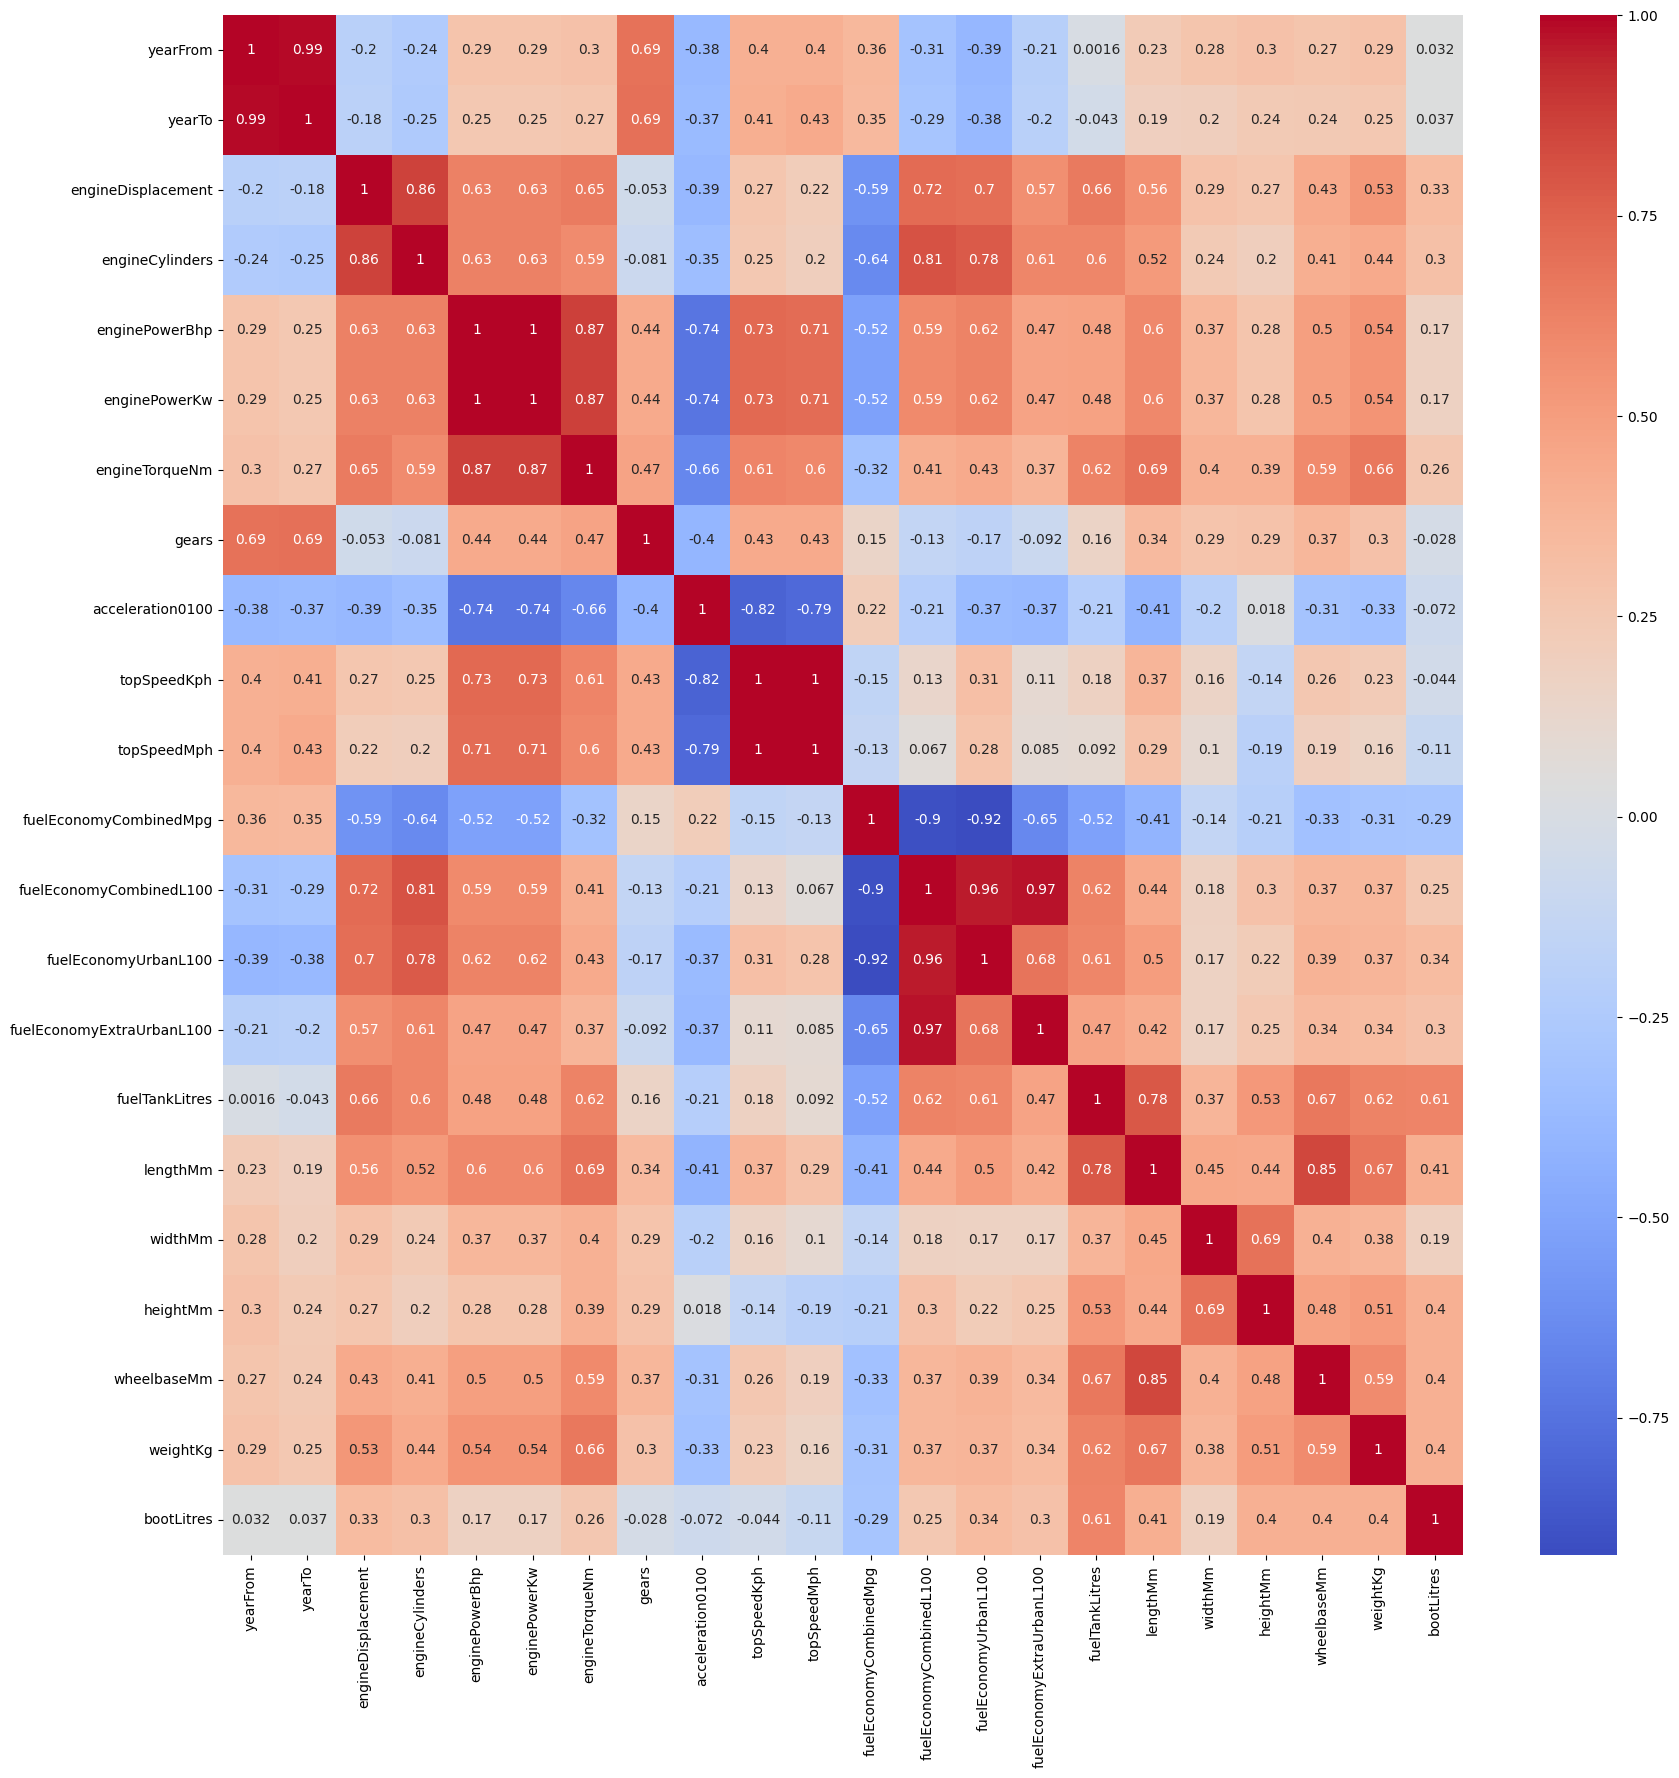

In [7]:
# Vendo quais colunas e importante para o estudo
num_cols = df.select_dtypes(np.number)
columns = [num_cols.columns]

plt.figure(figsize=(20, 20))
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.show()

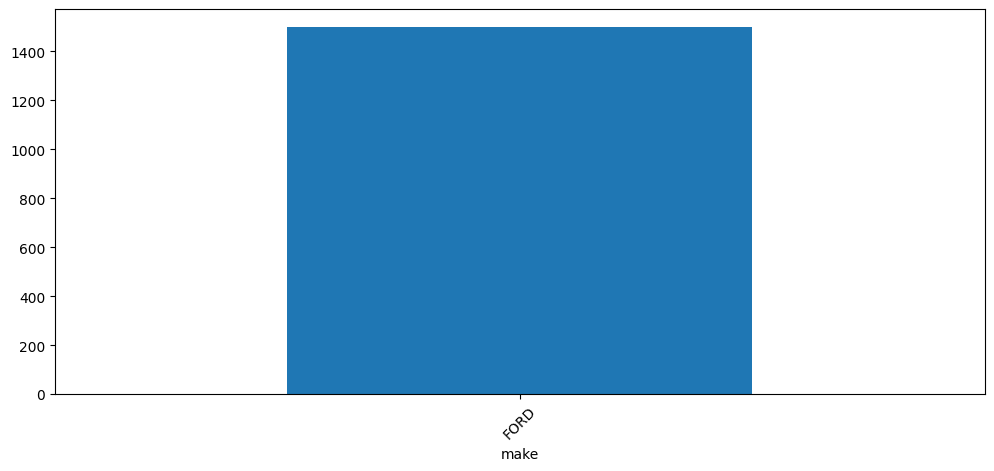

: 

In [ ]:
# Plotando densidade 

plt.figure(figsize=(15, 10))

for i, col in enumerate(columns, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Densidade de {col}')

plt.tight_layout()
plt.show()

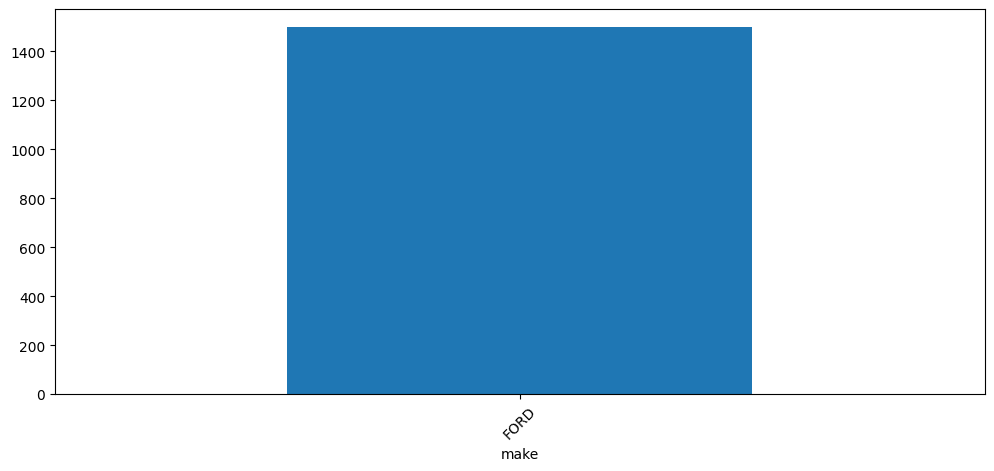

In [9]:
plt.figure(figsize=(12,5))

df['make'].value_counts().head(15).plot(kind='bar')

plt.xticks(rotation=45)

plt.show()

In [10]:
df['texto'] = (
    df[columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

print(df['texto'].head())

KeyError: "None of [Index([('yearFrom', 'yearTo', 'engineDisplacement', 'engineCylinders', 'enginePowerBhp', 'enginePowerKw', 'engineTorqueNm', 'gears', 'acceleration0100', 'topSpeedKph', 'topSpeedMph', 'fuelEconomyCombinedMpg', 'fuelEconomyCombinedL100', 'fuelEconomyUrbanL100', 'fuelEconomyExtraUrbanL100', 'fuelTankLitres', 'lengthMm', 'widthMm', 'heightMm', 'wheelbaseMm', 'weightKg', 'bootLitres')], dtype='object')] are in the [columns]"

In [ ]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

embeddings = model.encode(
    df['texto'].tolist(),
    show_progress_bar=True
)

print(embeddings.shape)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(
    embeddings
)

df['cluster'] = labels

In [ ]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        embeddings
    )

    score = silhouette_score(
        embeddings,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("Silhouette")

plt.grid()

plt.show()